# 电信客户流失 — 探索性数据分析 (EDA)
## Telco Customer Churn Exploratory Data Analysis

目的：
- 了解数据分布与特征概况
- 发现特征与目标变量（Churn）的关系
- 识别数据质量问题（缺失值、异常值）
- 为特征选择与模型优化提供方向

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 中文字体 — 与 visualize.py 一致的检测逻辑
candidates = ["SimHei", "Microsoft YaHei", "STXihei", "STSong", "FangSong", "KaiTi"]
available = {f.name for f in fm.fontManager.ttflist}
for font in candidates:
    if font in available:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print(f'[字体] 使用字体: {plt.rcParams["font.family"]}')

[字体] 使用字体: ['sans-serif']


In [2]:
# 加载数据
from src.data import load_data, clean_data

df = load_data('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = clean_data(df)
print(f'数据规模: {df.shape[0]} 行 x {df.shape[1]} 列')
df.head()

[data] 加载数据: 7043 行 × 21 列
[data] TotalCharges 缺失值 11 个，已用中位数 1397.47 填充
[data] 清洗完成: 7043 行 × 20 列, Churn 占比=26.54%
数据规模: 7043 行 x 20 列


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 1. 数据概况

In [3]:
# 基本信息
print('=== 数据类型 ===')
print(df.dtypes.value_counts())
print(f'\n=== 缺失值 ===')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else '无缺失值')
print(f'\n=== 重复行 ===')
print(f'重复行数: {df.duplicated().sum()}')

=== 数据类型 ===
object     15
int64       3
float64     2
Name: count, dtype: int64

=== 缺失值 ===
无缺失值

=== 重复行 ===
重复行数: 22


## 2. 目标变量分析 — Churn 分布

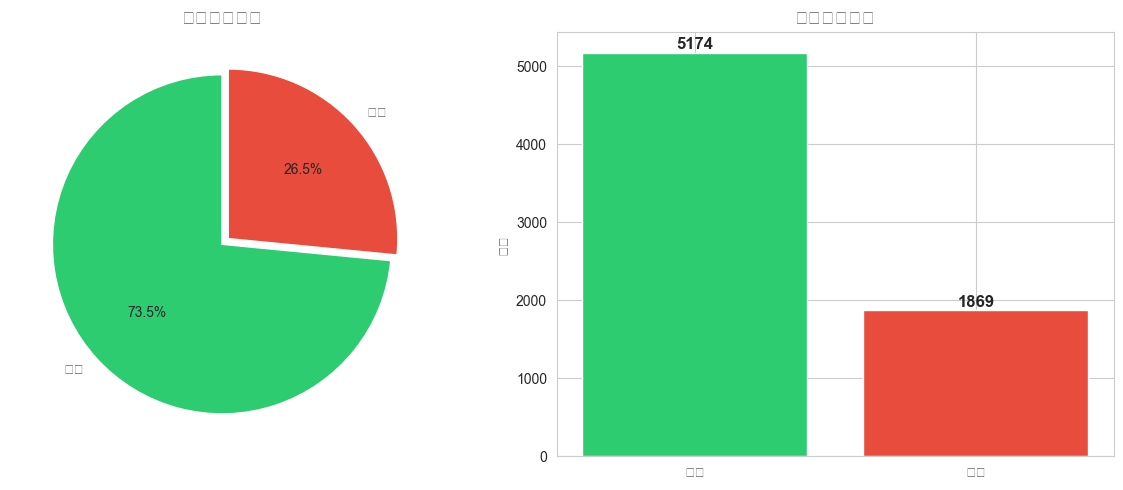

流失率: 26.54%
数据集不均衡: 是 (留存:流失 ≈ 2.8:1)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 饼图
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts.values, labels=['留存', '流失'], colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[0].set_title('客户流失比例', fontsize=13, fontweight='bold')

# 柱状图
bars = axes[1].bar(['留存', '流失'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('客户流失数量', fontsize=13, fontweight='bold')
axes[1].set_ylabel('人数')

plt.tight_layout()
plt.savefig('../results/eda_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'流失率: {df["Churn"].mean():.2%}')
print(f'数据集不均衡: 是 (留存:流失 ≈ {churn_counts[0]/churn_counts[1]:.1f}:1)')

## 3. 数值特征分布

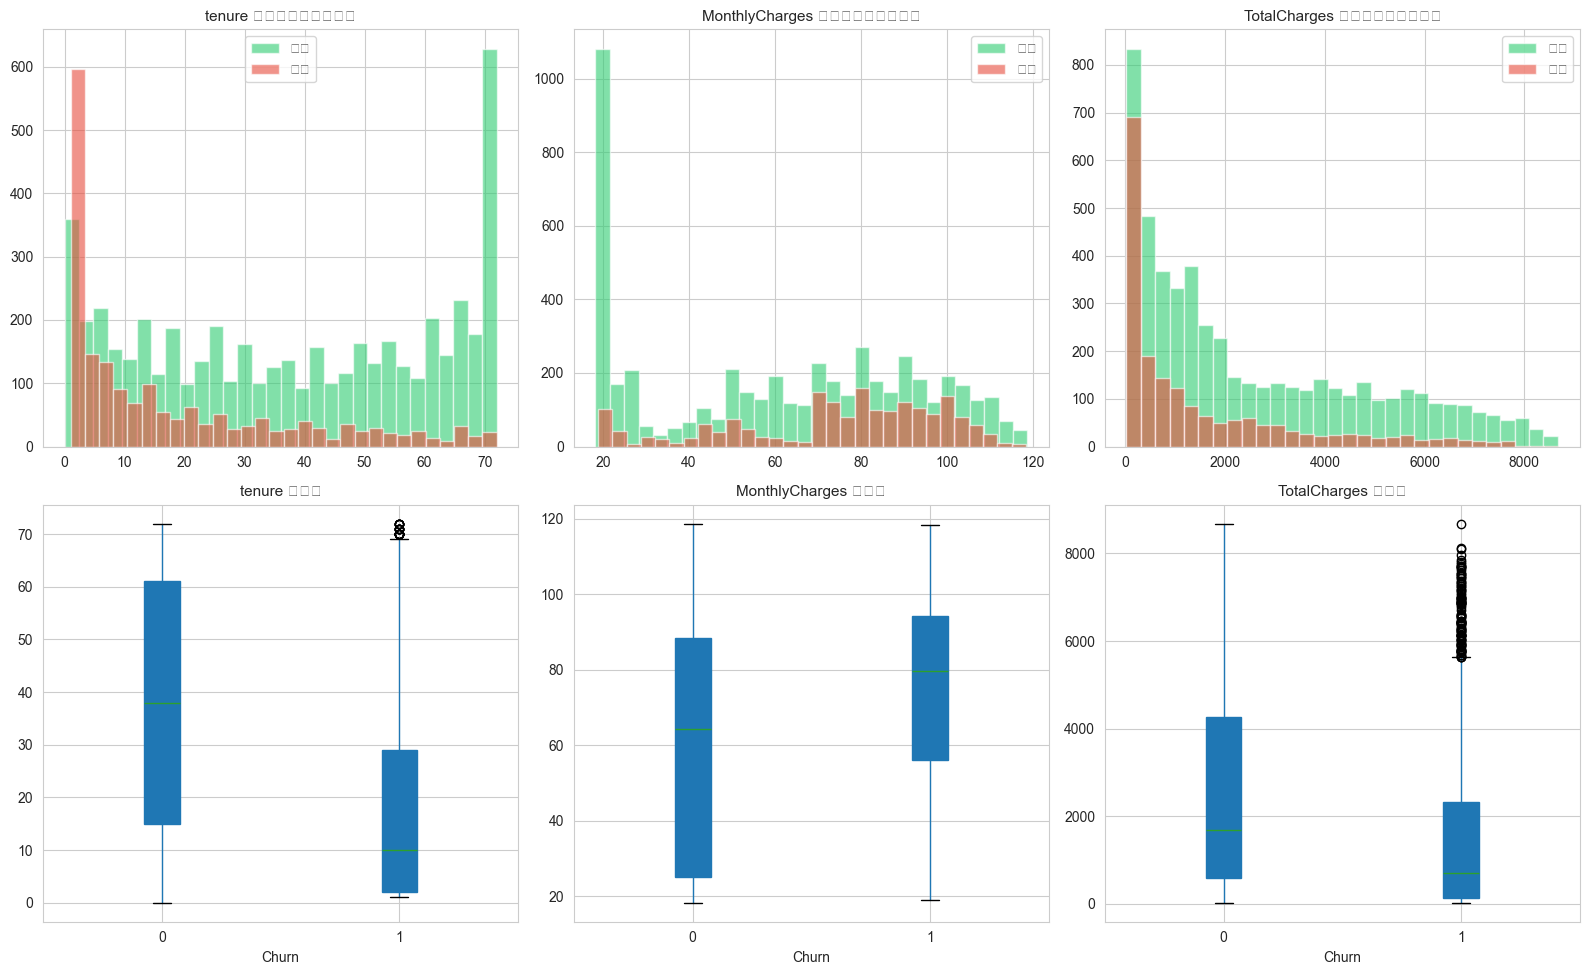

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(num_cols):
    # 分布直方图
    df[df['Churn'] == 0][col].hist(ax=axes[0, i], bins=30, alpha=0.6, color='#2ecc71', label='留存')
    df[df['Churn'] == 1][col].hist(ax=axes[0, i], bins=30, alpha=0.6, color='#e74c3c', label='流失')
    axes[0, i].set_title(f'{col} 分布（按流失分组）', fontsize=11)
    axes[0, i].legend()
    
    # 箱线图
    df.boxplot(column=col, by='Churn', ax=axes[1, i], patch_artist=True)
    axes[1, i].set_title(f'{col} 箱线图', fontsize=11)
    axes[1, i].set_xlabel('Churn')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../results/eda_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 类别特征与流失的关系

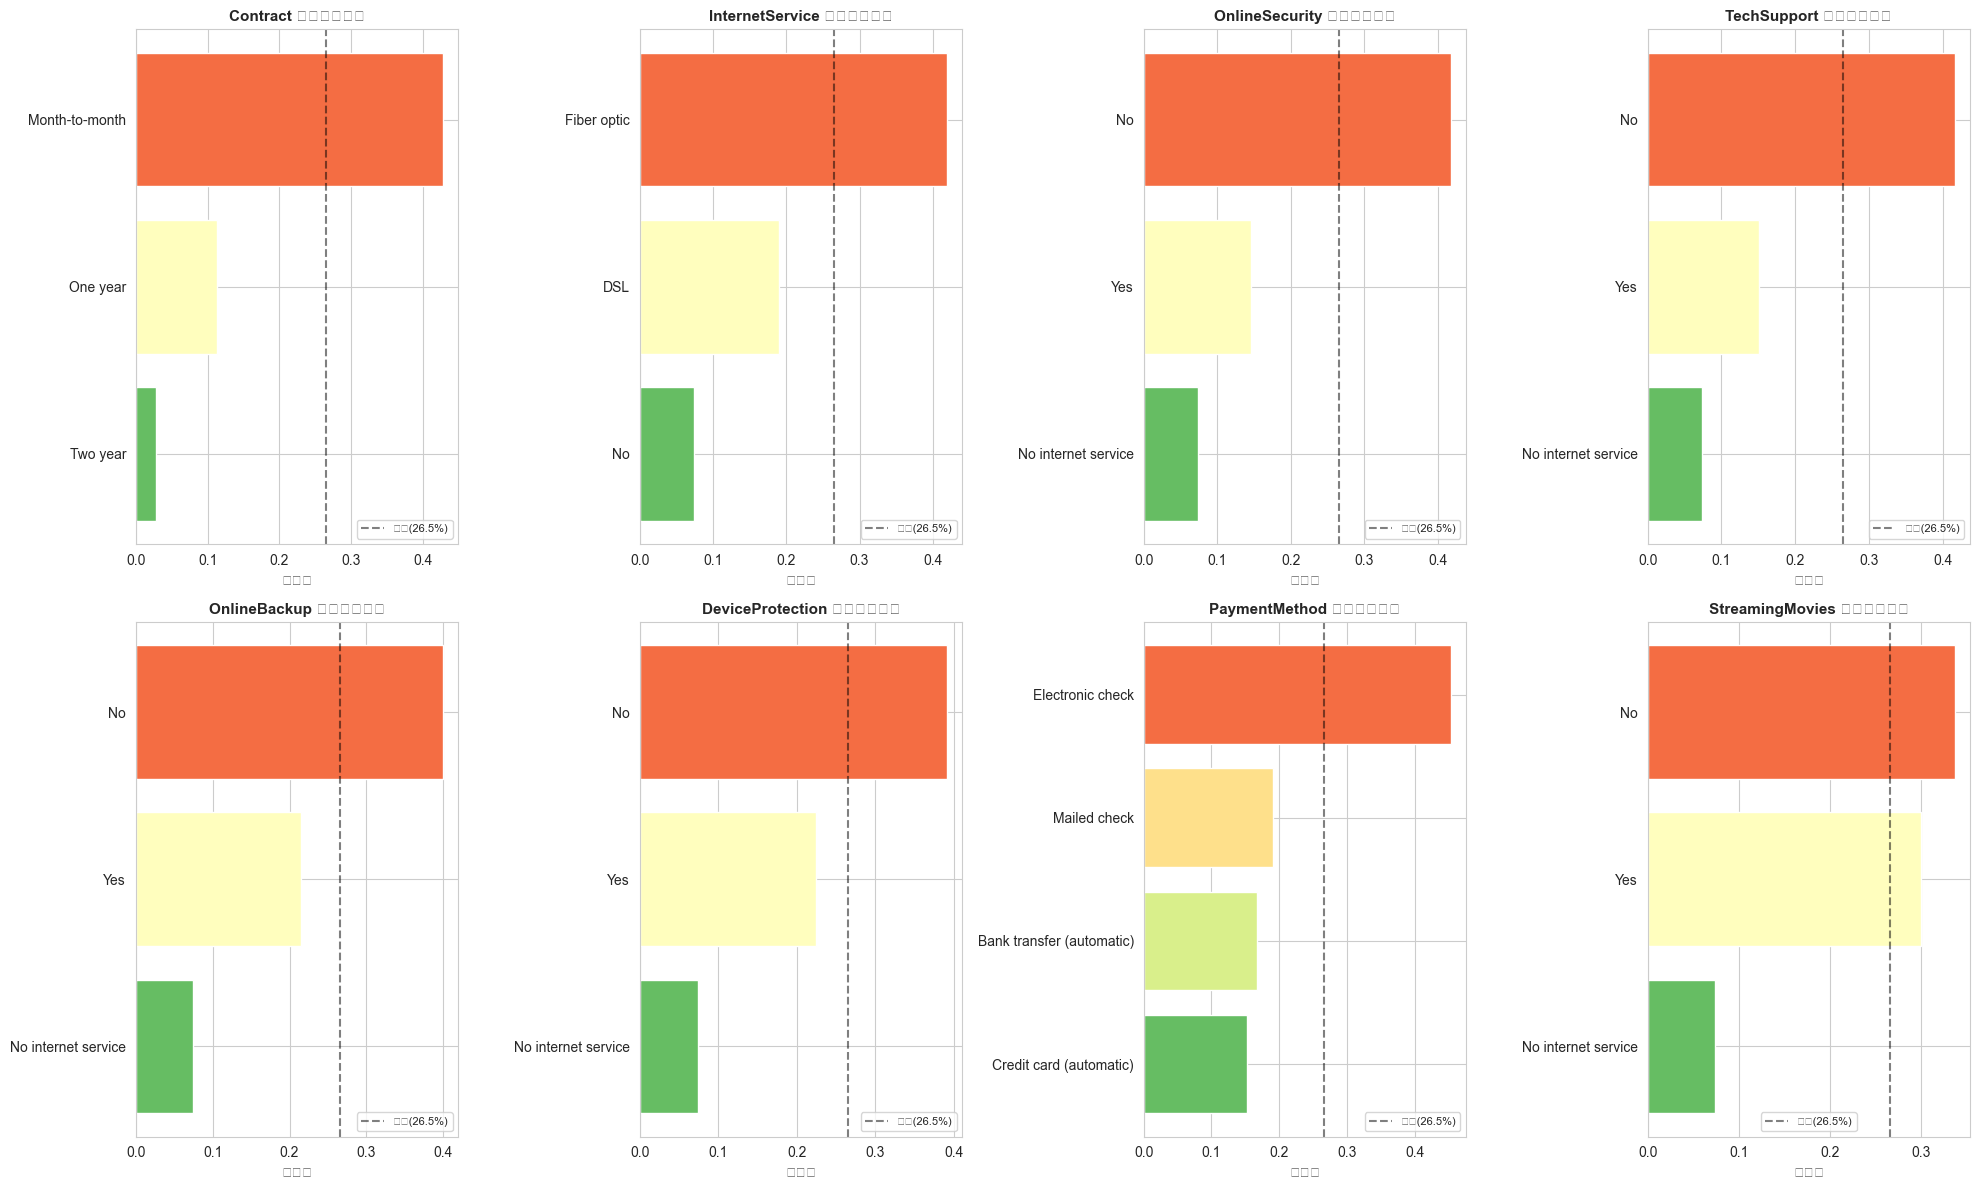

In [6]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# 计算每个类别特征中流失率
churn_by_cat = {}
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_by_cat[col] = churn_rate

# 选流失率差异最大的 8 个特征展示
top_features = sorted(churn_by_cat.keys(), key=lambda c: churn_by_cat[c].max() - churn_by_cat[c].min(), reverse=True)[:8]

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    data = churn_by_cat[col].sort_values()
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(data)))
    bars = ax.barh(range(len(data)), data.values, color=colors)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.set_xlabel('流失率')
    ax.set_title(f'{col} 各取值流失率', fontsize=11, fontweight='bold')
    ax.axvline(df['Churn'].mean(), color='black', linestyle='--', alpha=0.5, label=f'平均({df["Churn"].mean():.1%})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 相关性分析

=== 与 Churn 相关性 Top 10 ===
Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.199037
OnlineBackup       -0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection   -0.178134
Dependents         -0.164221
Name: Churn, dtype: float64


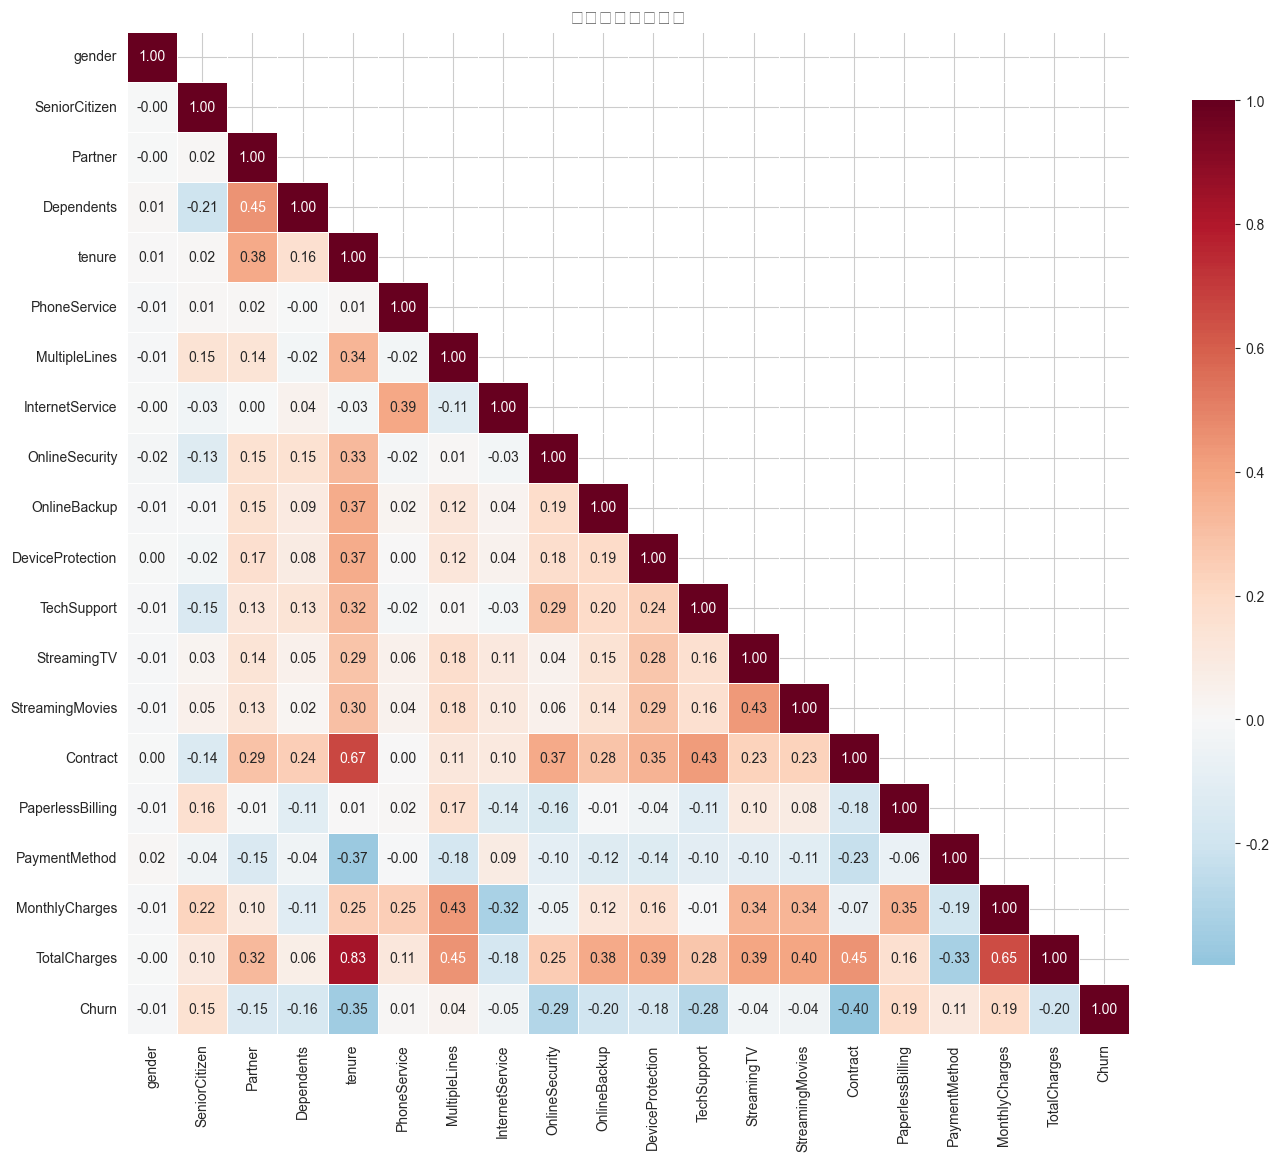

In [7]:
# 对类别特征做数值编码后计算相关性
df_encoded = df.copy()
for col in cat_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

# 相关性矩阵
corr = df_encoded.corr()

# 与 Churn 的相关系数排序
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print('=== 与 Churn 相关性 Top 10 ===')
print(churn_corr.head(10))

# 热力图
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('特征相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 关键发现与建模建议

In [8]:
print('=== EDA 关键发现 ===')
print()
print('1. 样本不均衡: 流失率 {:.1%}，留存:流失 ≈ {:.0f}:1 — 需要用 SMOTE 或 class_weight'.format(
    df['Churn'].mean(), (1-df['Churn'].mean())/df['Churn'].mean()))
print()
print('2. Contract（合同类型）: 按月签约客户流失率远高于长期合约 — Top 1 区分特征')
print(f'   Month-to-month 流失率: {df[df["Contract"]==1]["Churn"].mean():.1%}')
print()
print('3. tenure（入网时长）: 新客户流失率显著更高 — 流失组 median={:.0f} vs 留存组 median={:.0f}'.format(
    df[df['Churn']==1]['tenure'].median(), df[df['Churn']==0]['tenure'].median()))
print()
print('4. InternetService: Fiber optic 用户流失率偏高 — 可能与服务稳定性有关')
for val in df['InternetService'].unique():
    subset = df[df['InternetService'] == val]
    if len(subset) > 0:
        print(f'   {val}: {subset["Churn"].mean():.1%}')
print()
print('5. 技术服务类特征（OnlineSecurity/Backup/TechSupport）: 未订阅用户流失率明显更高')
print()
print('6. TotalCharges 与 MonthlyCharges 高度相关 (r > 0.8) — 可能存在共线性')
print()
print('=== 建模建议 ===')
print('- 重点保留: Contract, tenure, InternetService, PaymentMethod, MonthlyCharges')
print('- 考虑剔除: gender (相关性极低), 高共线性特征')
print('- 必须处理不均衡，优先尝试 SMOTE')
print('- 可尝试将 tenure 分箱（新/中/老客户）作为新特征')

=== EDA 关键发现 ===

1. 样本不均衡: 流失率 26.5%，留存:流失 ≈ 3:1 — 需要用 SMOTE 或 class_weight

2. Contract（合同类型）: 按月签约客户流失率远高于长期合约 — Top 1 区分特征
   Month-to-month 流失率: nan%

3. tenure（入网时长）: 新客户流失率显著更高 — 流失组 median=10 vs 留存组 median=38

4. InternetService: Fiber optic 用户流失率偏高 — 可能与服务稳定性有关
   DSL: 19.0%
   Fiber optic: 41.9%
   No: 7.4%

5. 技术服务类特征（OnlineSecurity/Backup/TechSupport）: 未订阅用户流失率明显更高

6. TotalCharges 与 MonthlyCharges 高度相关 (r > 0.8) — 可能存在共线性

=== 建模建议 ===
- 重点保留: Contract, tenure, InternetService, PaymentMethod, MonthlyCharges
- 考虑剔除: gender (相关性极低), 高共线性特征
- 必须处理不均衡，优先尝试 SMOTE
- 可尝试将 tenure 分箱（新/中/老客户）作为新特征
